In [ ]:
# import kagglehub
# # Download latest version
# path = kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset", output_dir='../data/raw')

## Imports

In [1]:
# Добавляем текущую директорию в путь
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, datasets
from pathlib import Path
from collections import Counter
import logging
import random
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

from src.data.dataset import(
    load_datasets, 
    create_dataloaders,
    get_dataset_info,
    denormalize_image,
    create_class_distribution_table
)

from src.utils import utils

%matplotlib inline

In [3]:
DIR = Path.cwd().parent

## SEED

In [4]:
# Фиксируем random seed для воспроизводимости
utils.set_seed(42)

# EDA

### Config load dataset

In [5]:
path_config_data = Path("../configs/data.yaml").absolute()
config_data = utils.load_config(path_config_data)

In [6]:
# Путь хранения датасета
path_data_load = Path(DIR, config_data["root_dir"])
# Загружам предварительно весь датасет
dataset = datasets.OxfordIIITPet(
        root=path_data_load,
        target_types='category',
        download=False)

### Show a set of image data before splitting

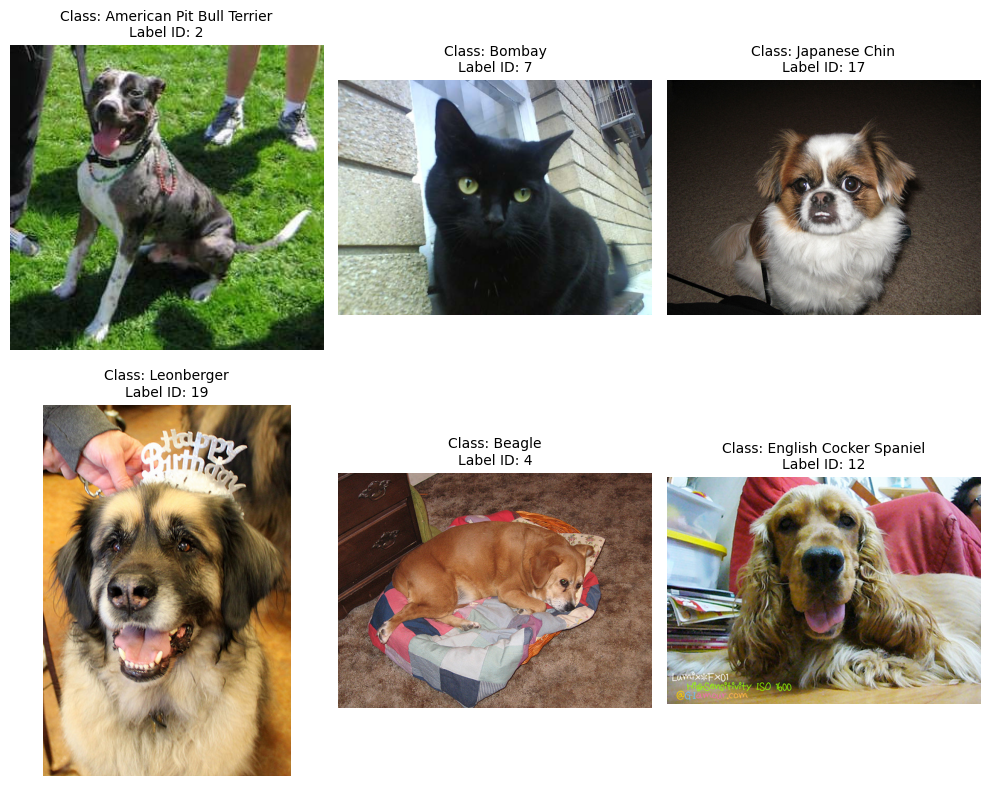

In [18]:
# Выбираем случайные индексы
random_indices = random.sample(range(len(dataset)), 6)

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    image, label = dataset[idx]
    axes[i].imshow(image)
    axes[i].set_title(f"Class: {dataset.classes[label]}\nLabel ID: {label}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()  # Автоматически подгоняет отступы
plt.show()

In [8]:
# Summary: Изображения имеют разный масштаба.

### Split dataset

In [9]:
train_dataset, val_dataset = load_datasets(path_data_load, config_data["image_size"])

In [10]:
train_loader, val_loader = create_dataloaders(
        train_dataset,
        val_dataset,
        config_data['batch_size'],
        config_data['num_workers'])

In [11]:
# Создаем таблицу
df = create_class_distribution_table(train_dataset, val_dataset)

# Выводим с настройками для полного показа
with pl.Config(tbl_rows=38):  # 37 классов + 1 строка TOTAL
    print(df)

shape: (38, 5)
┌────────────────────────────┬─────────────┬────────────┬─────────┬────────┐
│ class_name                 ┆ train_count ┆ test_count ┆ train_% ┆ test_% │
│ ---                        ┆ ---         ┆ ---        ┆ ---     ┆ ---    │
│ str                        ┆ i64         ┆ i64        ┆ f64     ┆ f64    │
╞════════════════════════════╪═════════════╪════════════╪═════════╪════════╡
│ Abyssinian                 ┆ 100         ┆ 98         ┆ 2.72    ┆ 2.67   │
│ American Bulldog           ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ American Pit Bull Terrier  ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ Basset Hound               ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ Beagle                     ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ Bengal                     ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ Birman                     ┆ 100         ┆ 100        ┆ 2.72    ┆ 2.73   │
│ Bombay                     ┆ 96          ┆ 88         ┆ 2.6

In [12]:
# В каждом классе по 200 изображений и по 100 на тренировочную и тестовую. Нет дисбаланса классов.

### Show a train set of image data after splitting

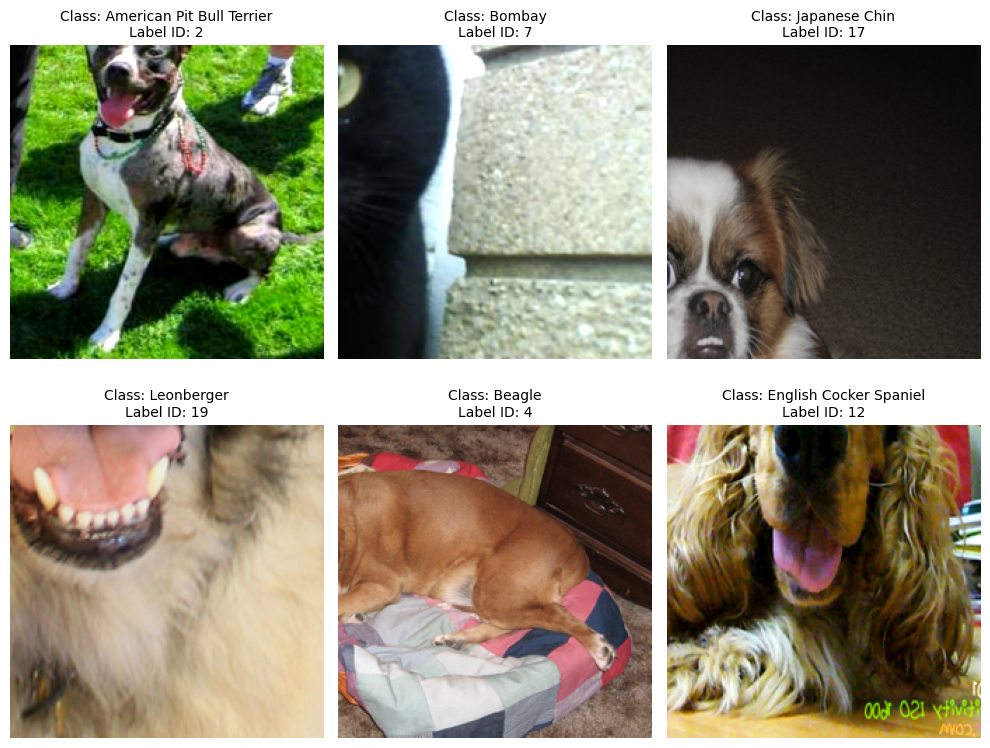

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    image, label = train_dataset[idx]
    image = denormalize_image(image)
    image = (image * 255).astype(np.uint8)
    
    axes[i].imshow(image)
    axes[i].set_title(f"Class: {train_dataset.classes[label]}\nLabel ID: {label}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Resume

Классы сбалансированы, геометрические искажения отсутствуют.  
Загружаемые изображения после обработки выглядят приемлемо для обучения — цветовой контраст сохранён, объекты центрированы, шум минимален.